### 분석 목적
이 분석의 목적은  
**고객 이탈이 특정 시점에 집중되어 발생하는지를 확인**하는 것이다.

앞선 분석에서:
- 매출은 증가하고
- 고객 수와 주문 수도 함께 증가하며
- ARPU 또한 비교적 안정적으로 유지되고 있음을 확인했다.

그러나 이는 모두 **집계 지표(aggregate metric)** 기준의 관찰로,  
고객이 **얼마나 빠르게 이탈하는지**에 대한 답을 주지는 않는다.

따라서 본 단계에서는  
**고객의 첫 구매 시점을 기준으로 한 코호트 분석(cohort analysis)** 을 통해  
> “첫 구매 이후 몇 개월 차에 이탈이 집중되는가?”  
를 정량적으로 확인한다.

In [1]:
# [3-0] 라이브러리 불러오기 & 환경 설정
# - 분석에 필요한 기본 라이브러리 로드
# - 출력 옵션을 조정해 데이터 확인을 쉽게 함

import pandas as pd
import numpy as np

# pandas 출력 옵션 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
orders_base = pd.read_csv(
    "../data/processed/orders_base_delivered.csv",
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date"]
)

코호트 분석의 핵심은  
**모든 고객을 동일한 출발선에 세우는 것**이다.

본 분석에서는  
- 고객의 첫 구매가 발생한 시점을 기준으로 코호트를 정의한다.
- 이후 재구매 여부를 시간 경과(M+0, M+1, …)에 따라 추적한다.

⚠️ 주의:
- 배송 완료일 기준이 아닌 **구매 시점(order_purchase_timestamp)** 기준을 사용한다.
- 이는 재구매 의사 형성이 ‘구매 경험’ 직후부터 시작된다고 가정하기 위함이다.

In [3]:
# 고객별 첫 구매 시점 계산
first_purchase = (
    orders_base
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
    .rename(columns={"order_purchase_timestamp": "first_purchase_date"})
)

first_purchase.head()

,customer_unique_id,first_purchase_date
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42


In [4]:
# 전체 고객 수
n_customers = orders_base["customer_unique_id"].nunique()

# first_purchase 테이블의 행 수
n_first_purchase_rows = first_purchase.shape[0]

n_customers, n_first_purchase_rows

(93357, 93357)

customer_unique_id당 first_purchase_date가 정확히 1개씩 존재하는지”수치로 검증

In [5]:
# first_purchase에서 customer_unique_id 중복 여부
first_purchase["customer_unique_id"].duplicated().sum()

np.int64(0)

In [7]:
(
    first_purchase
    .groupby("customer_unique_id")["first_purchase_date"]
    .nunique()
    .value_counts()
)

first_purchase_date
1    93357
Name: count, dtype: int64

✔ 모든 고객은 단 하나의 first_purchase_date만 가진다.<br>
✔ 코호트 기준으로 사용해도 구조적 문제가 없다.

### 왜 코호트 리텐션을 보는가?

앞선 분석에서 우리는
- 매출은 증가하고,
- 주문 수와 고객 수도 함께 증가하며,
- ARPU 또한 안정적으로 유지되는 것처럼 보이는
‘겉보기에는 건강한 서비스’ 모습을 확인했다.

그러나 이 지표들은 모두 **집계(aggregate) 기준**으로,
고객이 **얼마나 오래 남아 있는지**,
그리고 **언제 가장 많이 이탈하는지**에 대해서는 답하지 못한다.

따라서 이 단계에서는
고객의 첫 구매 시점을 기준으로 한 코호트 분석을 통해
> “이탈이 집중되는 시점이 언제인가?”
를 직접 확인한다.

---
####  Step 3-2. 코호트 기준 컬럼 생성

In [8]:
# 고객별 첫 구매 월 (ohort Month)
first_purchase = (
    orders_base
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase["cohort_month"] = (
    first_purchase["order_purchase_timestamp"]
    .dt.to_period("M")
)

first_purchase.head()

,customer_unique_id,order_purchase_timestamp,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11


In [9]:
# 주문데이터에 chort_month 붙이기

orders_cohort = orders_base.merge(
    first_purchase[["customer_unique_id", "cohort_month"]],
    on="customer_unique_id",
    how="left"
)

orders_cohort.head()

,order_id,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date,payment_value,order_month,cohort_month
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10-10 21:25:13,38.71,2017-10,2017-09
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-08-07 15:27:45,141.46,2018-07,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08-17 18:06:29,179.12,2018-08,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-12-02 00:28:42,72.20,2017-11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02-16 18:17:02,28.62,2018-02,2018-02


####  Step 3-3. 고객 활동 월 & 코호트 경과 개월 계산

In [13]:


# 주문 발생 월
orders_cohort["order_month"] = (
    orders_cohort["order_purchase_timestamp"]
    .dt.to_period("M")
)

# 코호트 경과 개월 수 (M+0, M+1, ...)
orders_cohort["cohort_index"] = (
    orders_cohort["order_month"]
    - orders_cohort["cohort_month"]
).apply(lambda x: x.n)

#### Step 3-4. 코호트 리텐션 테이블 생성 (수치)

각 코호트(cohort_month) 고객들이
첫 구매 이후 N개월(cohort_index)에
몇 명이나 다시 구매했는지를 나타낸 테이블

	•	cohort_month : 고객의 첫 구매 월
	•	cohort_index : 첫 구매 이후 경과 개월 (M+0, M+1, …)
	•	customer_unique_id : 해당 시점에 재구매한 고객 수

In [15]:
cohort_table = (
    orders_cohort
    .groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index()
)

cohort_table.head(10)

,cohort_month,cohort_index,customer_unique_id
0,2016-10,0,262
1,2016-10,6,1
2,2016-10,9,1
3,2016-10,11,1
4,2016-10,13,1
5,2016-10,15,1
6,2016-10,17,1
7,2016-10,19,2
8,2016-10,20,2
9,2016-12,0,1


##### 같은 첫 구매 월(cohort_month)에 유입된 고객(각 월별 코호트)들이,
##### 첫 구매 이후 N개월이 지난 시점(cohort_index)에 다시 구매했는지”를
##### 고객 수(명 수)로 집계한 테이블임.

In [16]:
# [3-1-A] 코호트 명수 테이블 (히트맵용)

cohort_pivot = (
    cohort_table
    .pivot(
        index="cohort_month",
        columns="cohort_index",
        values="customer_unique_id"
    )
    .sort_index()
)

cohort_pivot.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,262.00,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,1.00,NaN,1.00,NaN,1.00,NaN,1.00,NaN,1.00,2.00,2.00
2016-12,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.00,2.00,2.00,1.00,3.00,1.00,3.00,1.00,1.00,NaN,3.00,1.00,5.00,3.00,1.00,1.00,2.00,3.00,1.00,NaN
2017-02,1628.00,3.00,5.00,2.00,7.00,2.00,4.00,3.00,2.00,3.00,2.00,5.00,2.00,3.00,2.00,1.00,1.00,3.00,NaN,NaN
2017-03,2503.00,11.00,9.00,10.00,9.00,4.00,4.00,8.00,8.00,2.00,9.00,3.00,5.00,3.00,4.00,6.00,2.00,3.00,NaN,NaN


In [17]:
# [3-1-B] 코호트 리텐션 비율 테이블

cohort_retention = cohort_pivot.divide(
    cohort_pivot[0], axis=0
)

cohort_retention = cohort_retention.round(4)
cohort_retention.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,1.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,0.01,0.01
2016-12,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-02,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
2017-03,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN


##### 코호트 리텐션 비율 계산 : 이 코호트 고객 중, 첫 구매 이후 N개월 시점에 몇 %가 다시 구매했는가”

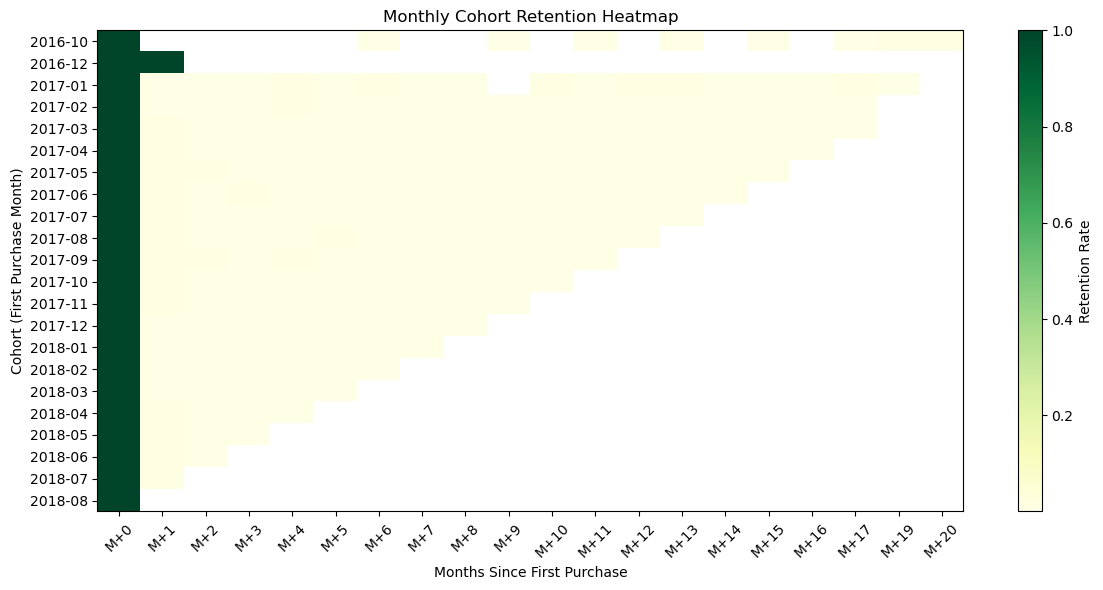

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.imshow(
    cohort_retention,
    aspect="auto",
    cmap="YlGn"
)

plt.colorbar(label="Retention Rate")

plt.xticks(
    ticks=range(len(cohort_retention.columns)),
    labels=[f"M+{i}" for i in cohort_retention.columns],
    rotation=45
)

plt.yticks(
    ticks=range(len(cohort_retention.index)),
    labels=cohort_retention.index.astype(str)
)

plt.title("Monthly Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort (First Purchase Month)")

plt.tight_layout()
plt.show()

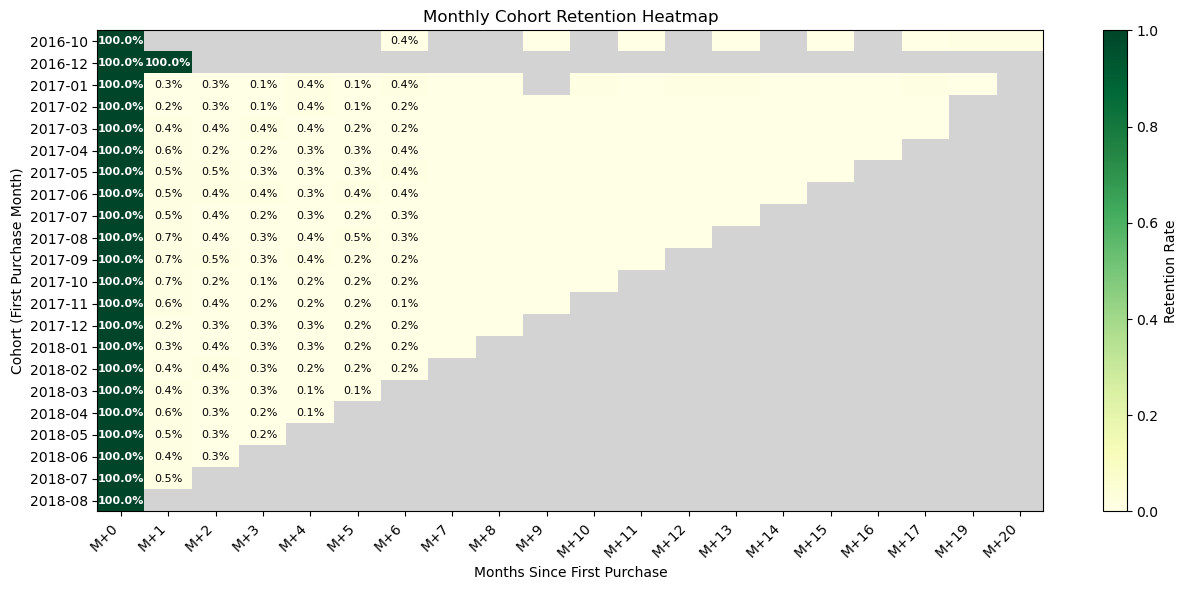

In [20]:
# [3-1-C-Upgrade] 히트맵 + 수치(%) 라벨 + 범례(colorbar) + NaN 마스킹

import numpy as np
import matplotlib.pyplot as plt

# 1) 리텐션 테이블 준비 (cohort_retention: index=cohort_month, columns=cohort_index)
ret = cohort_retention.copy()

# 2) NaN 마스킹 (관측 불가 구간을 색칠하지 않도록)
data = ret.to_numpy(dtype=float)
masked = np.ma.masked_invalid(data)  # NaN을 마스크 처리

# 3) colormap 설정: NaN은 회색으로 보이게
cmap = plt.cm.YlGn.copy()
cmap.set_bad(color="lightgray")  # NaN 영역 표시 색

fig, ax = plt.subplots(figsize=(13, 6))

im = ax.imshow(
    masked,
    aspect="auto",
    cmap=cmap,
    vmin=0, vmax=1   # 0~100% 스케일 고정(코호트끼리 비교 쉬움)
)

# 4) colorbar = 범례
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Retention Rate")

# 5) 축 라벨
ax.set_title("Monthly Cohort Retention Heatmap")
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Cohort (First Purchase Month)")

# x축 tick 라벨 (M+0, M+1...)
ax.set_xticks(range(ret.shape[1]))
ax.set_xticklabels([f"M+{i}" for i in ret.columns], rotation=45, ha="right")

# y축 tick 라벨
ax.set_yticks(range(ret.shape[0]))
ax.set_yticklabels(ret.index.astype(str))

# 6) 숫자 라벨 찍기 (너무 많으면 지저분 -> M+0~M+6까지만 추천)
max_month_to_annotate = 6  # 필요하면 3, 6, 12로 바꿔도 됨

for i in range(ret.shape[0]):      # row (cohort)
    for j in range(ret.shape[1]):  # col (month index)
        val = ret.iat[i, j]
        if np.isnan(val):
            continue
        if j <= max_month_to_annotate:
            # 👉 100%는 흰색, 나머지는 검정
            text_color = "white" if val >= 0.99 else "black"

            ax.text(
                j, i,
                f"{val*100:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
                fontweight="bold" if val >= 0.99 else "normal"
            )


plt.tight_layout()
plt.show()

핵심 관찰 ① — M+1에서 압도적인 급락
	•	모든 코호트에서 M+0 → M+1 구간에서 리텐션이 급격히 하락
	•	첫 구매 직후 다음 달에:
	•	90% 이상이 재구매하지 않음
	•	이는 특정 시기/코호트 문제가 아니라
구조적으로 반복되는 패턴

📌 해석

재구매 이탈의 대부분은
첫 구매 이후 한 달 이내에 발생한다

⸻

핵심 관찰 ② — M+2에서도 추가 급락, 이후 급속히 0에 수렴
	•	M+1 이후에도 M+2에서 한 번 더 유의미한 하락
	•	M+3 이후부터는:
	•	리텐션이 0.1~0.4% 수준
	•	사실상 0에 가까운 값으로 평탄화

📌 중요한 해석 포인트
	•	“안정화”처럼 보이지만,
	•	실제로는 극소수의 고객만 남아 있는 상태
	•	건강한 재구매 풀이라 보기 어려움

⸻

핵심 관찰 ③ — 계단형(삼각형) 구조의 의미

히트맵이 계단식으로 잘리는 이유는:
	•	데이터 관측 기간의 한계
	•	예:
	•	2018-08 코호트는 이후 몇 개월 데이터만 존재
	•	그 이후는 재구매 여부를 관측할 수 없음

📌 중요

이는 이탈이 아니라
“아직 관측되지 않은 구간”

##### 코호트별 리텐션 곡선 그리기 (급락 시점 확인용))

In [22]:
# [3-?-0] (필요 시) 코호트 리텐션 매트릭스(pivot) 만들기
# - cohort_table: (cohort_month, cohort_index, customer_unique_id) 형태
# - cohort_index: 첫 구매 후 경과월(0,1,2,...)
# - customer_unique_id: 해당 (cohort_month, cohort_index)에 구매한 유니크 고객 수

# pandas 개념:
# - pivot_table(): long -> wide (행/열 매트릭스)
# - div(): 행 단위로 나누기(리텐션율로 변환)

cohort_pivot = cohort_table.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id"
)

# 리텐션율(각 코호트의 M+0 대비 비율)
retention_matrix = cohort_pivot.div(cohort_pivot[0], axis=0)
retention_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,1.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,0.01,0.01
2016-12,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-02,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
2017-03,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN


In [23]:
# [3-?-A] retention_matrix 존재/형태 점검
# 목적:
# - 그래프가 안 나오는 1순위 원인: retention_matrix가 없거나 비어있음
# - shape/head로 "데이터가 실제로 들어있나" 확인

print("retention_matrix exists:", "retention_matrix" in globals())

# 아래 3개가 정상적으로 찍혀야 함
print("shape:", retention_matrix.shape)
display(retention_matrix.head())

# NaN 비율 점검 (거의 1.0이면 그래프가 사실상 안 나옴)
print("NaN ratio:", retention_matrix.isna().mean().mean())

retention_matrix exists: True
shape: (22, 20)


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,1.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,0.01,0.01
2016-12,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-02,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
2017-03,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN


NaN ratio: 0.5045454545454545


In [24]:
# [3-?-B] retention_matrix 컬럼을 "숫자 cohort_index"로 강제 정리
# 목적:
# - columns가 'M+0' 같은 문자열이면 plot 시 꼬이거나 정렬이 이상해질 수 있음
# - 숫자(int)로 통일해서 안정적으로 플로팅

rm = retention_matrix.copy()

def to_int_month(col):
    # col이 'M+3' 형태면 3으로
    if isinstance(col, str) and col.startswith("M+"):
        return int(col.replace("M+", ""))
    # col이 이미 숫자/정수면 그대로
    return int(col)

# 컬럼이 이미 int면 그대로, 'M+숫자'면 숫자로
rm.columns = [to_int_month(c) for c in rm.columns]

# 경과월 순서대로 정렬 (중요)
rm = rm.sort_index(axis=1)

# 전부 NaN인 컬럼은 제거 (그림 안 나오는 원인 제거)
rm = rm.dropna(axis=1, how="all")

print("fixed shape:", rm.shape)
display(rm.head())

fixed shape: (22, 20)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,1.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,0.01,0.01
2016-12,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-02,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
2017-03,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN


In [26]:
# [3-?-D] 리텐션 매트릭스 정규화 (진짜 retention rate 생성)
# 목적:
# - 각 코호트의 M+0 고객 수를 분모로
# - M+N 시점의 잔존 비율 계산

retention_rate = retention_matrix.copy()

# 각 코호트별 M+0 값으로 나누기
retention_rate = retention_rate.div(retention_rate[0], axis=0)

# 확인
display(retention_rate.head())
print("NaN ratio after normalization:", retention_rate.isna().mean().mean())

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-10,1.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,0.01,0.01
2016-12,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-02,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
2017-03,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN


NaN ratio after normalization: 0.5045454545454545


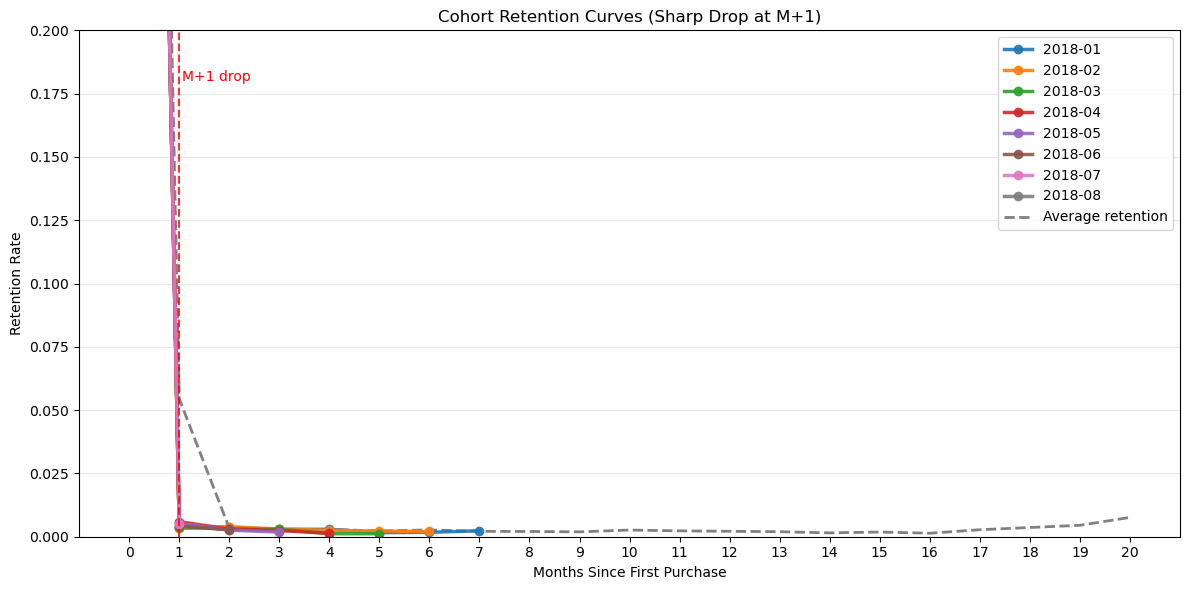

In [30]:
import matplotlib.pyplot as plt
import numpy as np

N = 8
plot_df = retention_rate.tail(N)

x = np.array(plot_df.columns, dtype=int)

plt.figure(figsize=(12, 6))

# 코호트별 선 (주인공)
for cohort in plot_df.index:
    plt.plot(
        x,
        plot_df.loc[cohort],
        linewidth=2.5,
        marker="o",
        alpha=0.9,
        label=str(cohort),
        zorder=2
    )

# 평균선 (보조)
avg_curve = retention_rate.mean(axis=0)
plt.plot(
    np.array(avg_curve.index, dtype=int),
    avg_curve.values,
    color="gray",
    linewidth=2,
    linestyle="--",
    label="Average retention",
    zorder=1
)

# M+1 강조
plt.axvline(1, linestyle="--", color="red", alpha=0.8)
plt.text(1.05, 0.18, "M+1 drop", color="red")

plt.title("Cohort Retention Curves (Sharp Drop at M+1)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Retention Rate")

# 🔥 이게 중요
plt.ylim(0, 0.2)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.xticks(np.arange(0, x.max() + 1, 1))
plt.show()

이 차트가 추가로 보여주는 것
	•	각 코호트의 리텐션 하락 ‘기울기’
	•	히트맵에서는 잘 안 보이던
**“언제 급락이 멈추는지”**를 선명하게 확인 가능

⸻

핵심 관찰 ④ — M+1, M+2 이중 급락 구조
	•	M+1: 가장 큰 급락 (1차 이탈)
	•	M+2: 추가 급락 (2차 이탈)
	•	M+3 이후:
	•	거의 모든 코호트가 0에 수렴
	•	이후 곡선은 “안정”이 아니라 “잔존 극소수”

📌 정리하면
	•	이탈은 한 번에 끝나지 않음
	•	첫 구매 후 1~2개월이 핵심 이탈 구간

재구매 이탈의 대부분은 첫 구매 이후 1~2개월 이내에 발생한다.
이후 남는 고객은 극히 소수이며,
이는 안정적인 재구매 구조라기보다는
잔존 고객만 남은 상태에 가깝다.

1️⃣ 로그 스케일 리텐션 곡선 (비교용)

목적

	•	M+1 이후 극소수 잔존 고객의 변화가 실제로 있는지
	•	“완전 0인가, 아주 낮은 수준에서 유지되는가” 확인

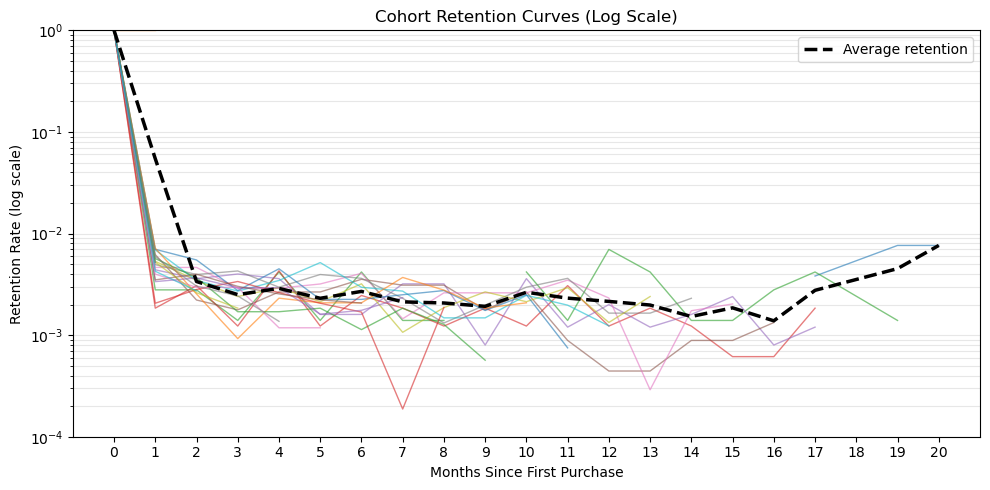

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

# 각 코호트별 리텐션 곡선
for cohort in retention_matrix.index:
    y = retention_matrix.loc[cohort]
    x = y.index.astype(int)

    plt.plot(
        x,
        y,
        alpha=0.6,
        linewidth=1
    )

# 평균 리텐션 곡선
avg_retention = retention_matrix.mean()
plt.plot(
    avg_retention.index.astype(int),
    avg_retention.values,
    color="black",
    linewidth=2.5,
    linestyle="--",
    label="Average retention"
)

# 🔥 핵심: 로그 스케일 적용
plt.yscale("log")

# 0은 로그에서 불가 → 하한선 설정
plt.ylim(1e-4, 1)

plt.xlabel("Months Since First Purchase")
plt.ylabel("Retention Rate (log scale)")
plt.title("Cohort Retention Curves (Log Scale)")

plt.xticks(range(0, int(avg_retention.index.max()) + 1))
plt.legend()
plt.grid(True, which="both", axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

	•	로그 스케일에서는 M+2 이후 곡선이 비교적 평탄해 보이지만,
	•	이는 안정적인 리텐션이 아니라
이미 극도로 축소된 모수 위에서의 작은 변동이다.

👉 해석 주의:

“리텐션이 안정화된다” ≠ “문제가 해결된다”

→ 이미 대부분의 고객은 M+1 이전에 이탈한 상태

✅ 필수 리텐션 분석 ①

Time-to-Second-Purchase (두 번째 구매까지 걸린 시간)


📌 왜 이 분석이 필수인가?
	•	코호트 히트맵에서 본 M+1 급락은
→ 사실상 **“두 번째 구매를 못 했다”**는 의미
	•	따라서 리텐션의 본질은
“첫 구매 이후 얼마 안에 재구매가 일어나는가”

👉 이 분석이 있어야
	•	30일 기준이 타당한지
	•	M+1이 왜 치명적인지
를 설명할 수 있음

### Time-to-Second-Purchase 분석
- 목적: 첫 구매 이후 두 번째 구매까지 걸린 시간 분포 확인
- 분석 단위: customer_unique_id
- 기준 시점: order_purchase_timestamp
- 산출 지표:
  - 재구매 고객 비율
  - 두 번째 구매까지 걸린 일수 분포
  - 30일 이내 재구매 비율

In [32]:
# 고객별 구매 시점 정렬
orders_sorted = (
    orders_base
    .sort_values(["customer_unique_id", "order_purchase_timestamp"])
    .copy()
)

orders_sorted.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,order_month,customer_unique_id
51239,e22acc9c116caa3f2b7121bbb380d08e,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21 00:00:00,141.90,2018-05,0000366f3b9a7992bf8c76cfdf3221e2
71695,3594e05a005ac4d06a72673270ef9ec9,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15 00:00:00,27.19,2018-05,0000b849f77a49e4a4ce2b2a4ca5be3f
25684,b33ec3b699337181488304f362a6b734,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07 00:00:00,86.22,2017-03,0000f46a3911fa3c0805444483337064
95556,41272756ecddd9a9ed0180413cc22fb6,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13 00:00:00,43.62,2017-10,0000f6ccb0745a6a4b88665a16c9f078
40330,d957021f1127559cd947b62533f484f7,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05 00:00:00,196.89,2017-11,0004aac84e0df4da2b147fca70cf8255


In [33]:
# 고객별 구매 순번 부여
orders_sorted["purchase_rank"] = (
    orders_sorted
    .groupby("customer_unique_id")
    .cumcount() + 1
)

orders_sorted.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,order_month,customer_unique_id,purchase_rank
51239,e22acc9c116caa3f2b7121bbb380d08e,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21 00:00:00,141.90,2018-05,0000366f3b9a7992bf8c76cfdf3221e2,1
71695,3594e05a005ac4d06a72673270ef9ec9,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15 00:00:00,27.19,2018-05,0000b849f77a49e4a4ce2b2a4ca5be3f,1
25684,b33ec3b699337181488304f362a6b734,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07 00:00:00,86.22,2017-03,0000f46a3911fa3c0805444483337064,1
95556,41272756ecddd9a9ed0180413cc22fb6,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13 00:00:00,43.62,2017-10,0000f6ccb0745a6a4b88665a16c9f078,1
40330,d957021f1127559cd947b62533f484f7,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05 00:00:00,196.89,2017-11,0004aac84e0df4da2b147fca70cf8255,1


In [34]:
# 3단계: 첫 구매 vs 두 번째 구매 테이블 만들기

first_purchase = orders_sorted[orders_sorted["purchase_rank"] == 1][
    ["customer_unique_id", "order_purchase_timestamp"]
].rename(columns={"order_purchase_timestamp": "first_purchase_date"})

second_purchase = orders_sorted[orders_sorted["purchase_rank"] == 2][
    ["customer_unique_id", "order_purchase_timestamp"]
].rename(columns={"order_purchase_timestamp": "second_purchase_date"})

# 병합
purchase_gap = first_purchase.merge(
    second_purchase,
    on="customer_unique_id",
    how="left"
)

purchase_gap.head()

,customer_unique_id,first_purchase_date,second_purchase_date
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,NaT
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,NaT
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,NaT
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,NaT
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,NaT


In [35]:
purchase_gap["days_to_second_purchase"] = (
    purchase_gap["second_purchase_date"] 
    - purchase_gap["first_purchase_date"]
).dt.days

purchase_gap.describe()

,first_purchase_date,second_purchase_date,days_to_second_purchase
count,93357,2801,2801.00
mean,2018-01-01 12:25:50.133583872,2018-01-14 20:33:57.490896128,80.84
min,2016-10-03 09:44:50,2016-10-07 08:28:29,0.00
25%,2017-09-13 16:03:18,2017-10-05 10:01:44,0.00
50%,2018-01-20 07:46:14,2018-02-03 09:27:17,28.00
75%,2018-05-05 14:16:29,2018-05-10 15:49:11,126.00
max,2018-08-29 15:00:37,2018-08-28 21:56:12,608.00
std,NaN,NaN,109.90


In [38]:
total_customers = purchase_gap.shape[0]
repeat_customers = purchase_gap["days_to_second_purchase"].notna().sum()

repeat_ratio = repeat_customers / total_customers * 100

repeat_ratio

np.float64(3.0003106355174225)

🔍 Step 3-3. 재구매 속도 분석 (Time to Second Purchase)

🎯 이 단계의 목적
	•	이탈이 ‘언제’ 확정되는지를 시간 관점에서 명확히 하기
	•	M+1 급락이
→ *“아예 재구매 의사가 없는 것”*인지
→ *“기다리면 돌아오는 고객이 있는 것”*인지 구분
	•	재구매 유도 정책의 골든타임(30·60·90일) 설정 근거 확보

In [10]:
# 고객별 주문 시점 정렬 테이블 만들기

customer_orders = (
    orders_base
    .sort_values(["customer_unique_id", "order_purchase_timestamp"])
    .loc[:, ["customer_unique_id", "order_purchase_timestamp"]]
)

In [11]:
# 고객별 구매 순서 붙이기

customer_orders["purchase_rank"] = (
    customer_orders
    .groupby("customer_unique_id")
    .cumcount() + 1
)

In [12]:
# 첫 구매 vs 두 번째 구매 테이블 만들기

first_purchase = (
    customer_orders[customer_orders["purchase_rank"] == 1]
    .rename(columns={"order_purchase_timestamp": "first_purchase_date"})
    .loc[:, ["customer_unique_id", "first_purchase_date"]]
)

second_purchase = (
    customer_orders[customer_orders["purchase_rank"] == 2]
    .rename(columns={"order_purchase_timestamp": "second_purchase_date"})
    .loc[:, ["customer_unique_id", "second_purchase_date"]]
)

In [13]:
#  하나로 합치기 (LEFT JOIN 중요)
customer_purchase_dates = first_purchase.merge(
    second_purchase,
    on="customer_unique_id",
    how="left"
)

In [14]:
# 두 구매 사이 일수 계산
customer_purchase_dates["days_to_second_purchase"] = (
    customer_purchase_dates["second_purchase_date"]
    - customer_purchase_dates["first_purchase_date"]
).dt.days

In [15]:
customer_purchase_dates.head()
customer_purchase_dates["days_to_second_purchase"].describe()

count   2801.00
mean      80.84
std      109.90
min        0.00
25%        0.00
50%       28.00
75%      126.00
max      608.00
Name: days_to_second_purchase, dtype: float64

🔍 Step 3-4. 기간 기준 재구매율 분석

(Retention Window Analysis)<br>
  

🎯 이 단계의 목적<br>
	•	“재구매 고객은 언제까지를 봐야 의미가 있는가?”에 답하기<br>
	•	코호트 히트맵의 M+1 급락을 → **정책적으로 해석 가능한 ‘기간’**으로 번역, 30일 60일 90일 <br>
	•	👉 CRM / 리마케팅 골든타임 정의

In [16]:
windows = [30, 60, 90, 180, 365, 730]

In [17]:
total_customers = customer_purchase_dates.shape[0]

retention_summary = []

for w in windows:
    retained = (
        customer_purchase_dates["days_to_second_purchase"]
        .le(w)          # w일 이내 재구매
        .sum()
    )
    
    retention_summary.append({
        "window_days": w,
        "retained_customers": retained,
        "retention_rate_pct": retained / total_customers * 100
    })

retention_df = pd.DataFrame(retention_summary)
retention_df

,window_days,retained_customers,retention_rate_pct
0,30,1423,1.52
1,60,1718,1.84
2,90,1912,2.05
3,180,2322,2.49
4,365,2719,2.91
5,730,2801,3.00


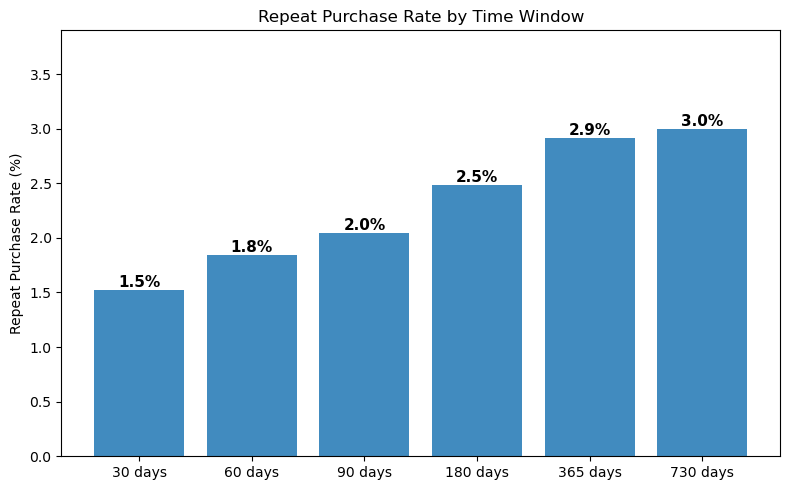

In [18]:
import matplotlib.pyplot as plt

x = retention_df["window_days"].astype(str) + " days"
y = retention_df["retention_rate_pct"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    x, y,
    alpha=0.85
)

plt.title("Repeat Purchase Rate by Time Window")
plt.ylabel("Repeat Purchase Rate (%)")
plt.ylim(0, max(y) * 1.3)

# 퍼센트 라벨
for bar, pct in zip(bars, y):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

“재구매 고객의 거의 전부는 첫 구매 후 1년 이내에 결정된다.”
“1년 이후 관측되는 재구매는 예외적이며, 전략적 대상이 되기 어렵다.”

### Step 3-5. 재구매 성공 고객 vs 이탈 고객 비교

앞선 분석에서,
- 재구매의 대부분은 첫 구매 이후 6개월 이내에 발생하며
- 6개월 이후 추가 재구매율 증가는 매우 제한적임을 확인하였다.

이에 따라 본 단계에서는  
**첫 구매 이후 6개월 이내 재구매 고객을 ‘전환 성공 고객’,  
6개월 초과 미재구매 고객을 ‘이탈 고객’으로 정의**하고,

두 집단 간의 **초기 구매 경험 차이**를 비교하여  
“어디서 갈렸는가?”를 확인한다.

In [19]:
#분석용 고객 라벨 생성 
# 기준 	
# •	days_to_second_purchase ≤ 180 → 재구매 고객
#	NaN or > 180 → 이탈 고객
df = customer_purchase_dates.copy()

df["segment"] = np.where(
    df["days_to_second_purchase"].le(180),
    "Repurchased ≤ 6M",
    "Churned > 6M"
)

df["segment"].value_counts(normalize=True) * 100

segment
Churned > 6M       97.51
Repurchased ≤ 6M    2.49
Name: proportion, dtype: float64

<Figure size 700x500 with 0 Axes>

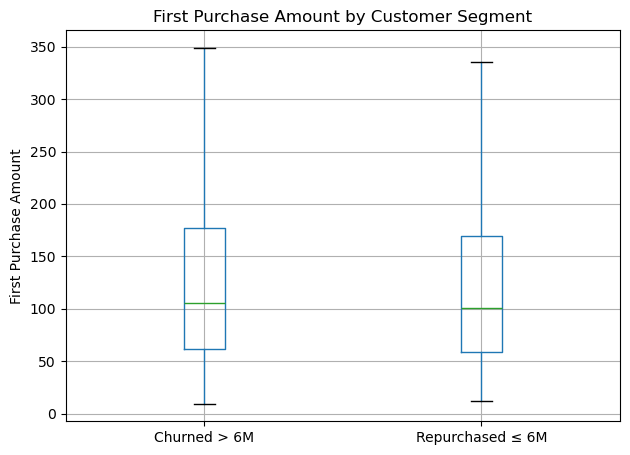

In [20]:
# 첫 구매 금액 비교 
# 데이터 준비

first_orders = (
    orders_base
    .sort_values("order_purchase_timestamp")
    .groupby("customer_unique_id")
    .first()
    .reset_index()
)

df_amount = df.merge(
    first_orders[["customer_unique_id", "payment_value"]],
    on="customer_unique_id",
    how="left"
)

#시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

df_amount.boxplot(
    column="payment_value",
    by="segment",
    showfliers=False
)

plt.title("First Purchase Amount by Customer Segment")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("First Purchase Amount")

plt.tight_layout()
plt.show()

🎯 분석 질문

“재구매 고객은 첫 구매에서 더 많은 금액을 지불했을까?”

⸻

📊 차트 설명
	•	비교 대상
	•	Churned > 6M: 첫 구매 후 6개월 이상 재구매하지 않은 고객
	•	Repurchased ≤ 6M: 첫 구매 후 6개월 이내 재구매한 고객
	•	지표: 고객별 첫 구매 금액
	•	시각화: 박스플롯
	•	중앙값(median)
	•	사분위 범위(IQR)
	•	이상치(outlier)는 제거하여 일반적인 분포에 집중

⸻

🔍 관찰 결과
	•	두 그룹의 중앙값은 거의 동일
	•	약 100 내외
	•	사분위 범위(IQR) 또한 크게 겹침
	•	재구매 고객이
	•	첫 구매에서 뚜렷하게 더 많이 지불했다고 보기 어려움
	•	분포 형태 역시 두 그룹 간 유사

⸻

🧠 해석
	•	첫 구매 금액은 재구매 여부를 설명하지 못한다
	•	즉,
“처음에 많이 쓴 고객이 다시 오는 구조”가 아니다
	•	재구매는 가격 요인보다는 경험 요인에 더 가까울 가능성이 큼
	•	배송 경험
	•	신뢰
	•	만족도
	•	구매 과정의 편의성 등

⸻

📌 핵심 메시지 (발표용 한 줄)

“재구매 고객과 이탈 고객은 첫 구매 금액에서 유의미한 차이를 보이지 않는다.”

---
🚚 Step 3-5. 배송 소요 시간 비교 분석

🎯 이 단계의 목적

“배송 경험(속도)이 재구매 여부와 관련이 있는가?”

	•	첫 구매 금액은 차이가 없었음
	•	그렇다면 첫 구매 ‘경험’, 특히 배송이 달랐을 가능성 검증
	•	비교 대상:
	•	6개월 내 재구매 고객
	•	6개월 초과 미재구매 고객(이탈)

In [21]:
# 배송 소요 시간 = 배송 완료일 - 구매 시점
# 기준 테이블: orders_base

first_orders = (
    orders_base
    .sort_values("order_purchase_timestamp")
    .groupby("customer_unique_id")
    .first()
    .reset_index()
)

first_orders["delivery_days"] = (
    first_orders["order_delivered_customer_date"]
    - first_orders["order_purchase_timestamp"]
).dt.days

# 고객 세그먼트(df)에 배송 정보 병합
df_delivery = df.merge(
    first_orders[["customer_unique_id", "delivery_days"]],
    on="customer_unique_id",
    how="left"
)

df_delivery[["segment", "delivery_days"]].head()

,segment,delivery_days
0,Churned > 6M,6.00
1,Churned > 6M,3.00
2,Churned > 6M,25.00
3,Churned > 6M,20.00
4,Churned > 6M,13.00


<Figure size 700x500 with 0 Axes>

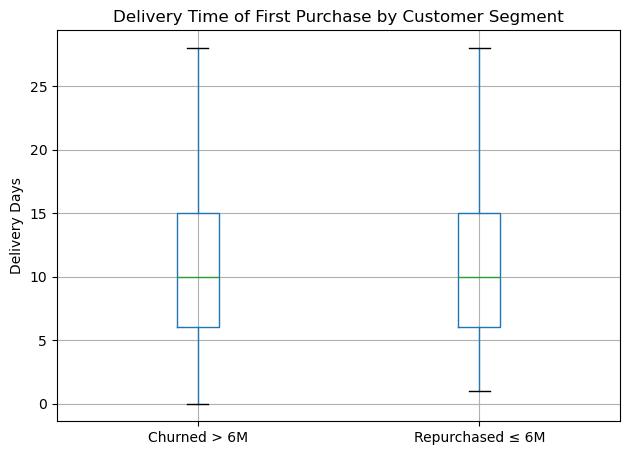

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

df_delivery.boxplot(
    column="delivery_days",
    by="segment",
    showfliers=False
)

plt.title("Delivery Time of First Purchase by Customer Segment")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("Delivery Days")

plt.tight_layout()
plt.show()

첫 구매 금액과 배송 소요 시간 모두에서
재구매 고객과 이탈 고객 간 유의미한 차이는 발견되지 않았다.

이는 Olist의 낮은 리텐션 문제가
가격이나 배송 품질 같은 전통적인 운영 지표보다는,
첫 구매 이후 고객과의 관계가 이어지지 않는
구조적 문제일 가능성이 높음을 시사한다.

### 분석 목적
첫 구매 이후 고객이 리뷰를 작성했는지가
재구매 여부와 어떤 관계가 있는지를 확인한다.

이를 통해
- 리뷰가 단순한 피드백인지,
- 아니면 고객이 서비스와 ‘관계를 맺었다’는 신호인지
를 검증한다.

In [23]:
# 리뷰 데이터 로드 (리텐션/리뷰 분석용)
reviews = pd.read_csv(
    "../data/raw/olist_order_reviews_dataset.csv"
)

reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [24]:
# [1] 첫 구매 주문 추출 (이미 만들었으면 skip)
first_orders = (
    orders_base
    .sort_values("order_purchase_timestamp")
    .groupby("customer_unique_id")
    .first()
    .reset_index()
)

# [2] 리뷰 테이블에서 리뷰가 있는 주문 id 추출
reviewed_orders = reviews["order_id"].unique()

# [3] 첫 구매 주문에 리뷰 여부 플래그 생성
first_orders["has_review"] = first_orders["order_id"].isin(reviewed_orders)

# 확인
first_orders["has_review"].value_counts(normalize=True) * 100

has_review
True    99.34
False    0.66
Name: proportion, dtype: float64

🔢 수치 결과
	•	첫 구매 주문 중 리뷰가 존재한 비율: 99.34%
	•	리뷰가 없는 첫 구매 주문 비율: 0.66%

1️⃣ 리뷰 데이터 커버리지는 사실상 100%
	•	Olist 데이터에서는
“첫 구매 → 리뷰 작성”이 거의 자동으로 발생하는 구조임
	•	즉,
	•	리뷰 작성 여부 자체는
	•	재구매를 가르는 강력한 구분 변수는 아님

👉 “리뷰를 썼느냐 안 썼느냐” 보다는
👉 “어떤 리뷰를 남겼느냐”가 중요

In [25]:
# 첫 구매 주문의 리뷰 점수 가져오기
first_orders_reviews = first_orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

# 세그먼트(df)에 리뷰 점수 붙이기
df_review = df.merge(
    first_orders_reviews[["customer_unique_id", "review_score"]],
    on="customer_unique_id",
    how="left"
)

df_review[["segment", "review_score"]].head()

,segment,review_score
0,Churned > 6M,5.00
1,Churned > 6M,4.00
2,Churned > 6M,3.00
3,Churned > 6M,4.00
4,Churned > 6M,5.00


<Figure size 700x500 with 0 Axes>

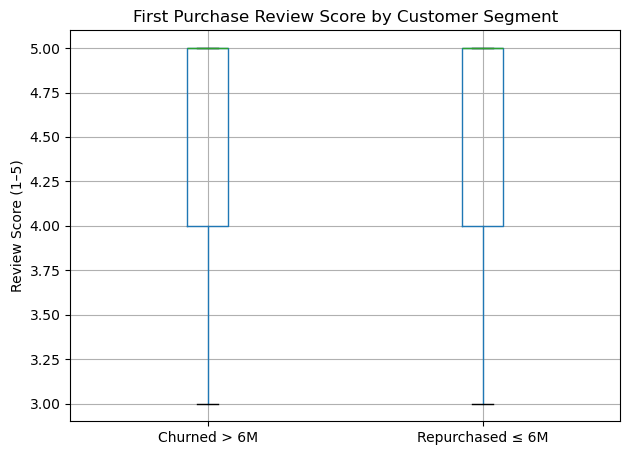

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

df_review.boxplot(
    column="review_score",
    by="segment",
    showfliers=False
)

plt.title("First Purchase Review Score by Customer Segment")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("Review Score (1–5)")

plt.tight_layout()
plt.show()

---
30일 기준 재구매 고객 정의 후 다시 고객경험 중심으로 이탈 원인을 분석해본다. 

In [27]:
# 30일 기준 재구매 플래그
df_30 = customer_purchase_dates.copy()

df_30["repurchased_30d"] = df_30["days_to_second_purchase"].le(30)

# 비율 확인
repurchase_30_summary = (
    df_30["repurchased_30d"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
)

repurchase_30_summary

repurchased_30d
False   98.48
True     1.52
Name: pct, dtype: float64

In [28]:
windows = [30, 90, 180, 365]

summary = []

total = customer_purchase_dates.shape[0]

for w in windows:
    retained = customer_purchase_dates["days_to_second_purchase"].le(w).sum()
    summary.append({
        "window_days": w,
        "retention_rate": retained / total * 100
    })

retention_window_df = pd.DataFrame(summary)
retention_window_df

,window_days,retention_rate
0,30,1.52
1,90,2.05
2,180,2.49
3,365,2.91


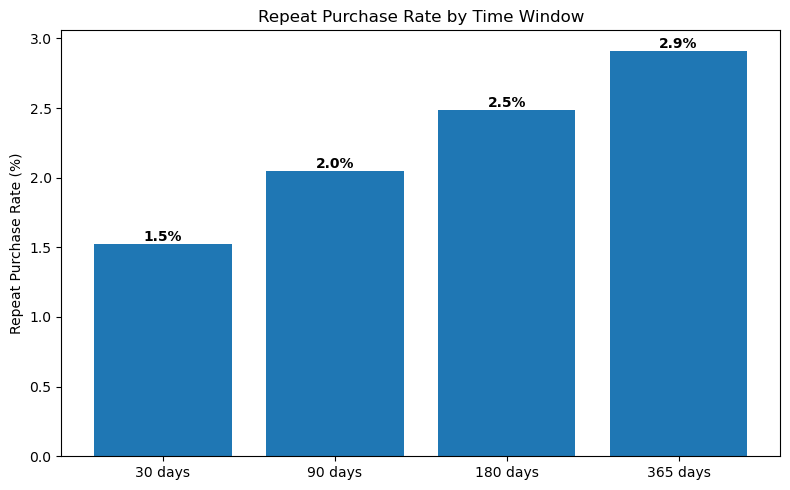

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    retention_window_df["window_days"].astype(str) + " days",
    retention_window_df["retention_rate"]
)

for i, v in enumerate(retention_window_df["retention_rate"]):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontweight="bold")

plt.ylabel("Repeat Purchase Rate (%)")
plt.title("Repeat Purchase Rate by Time Window")
plt.tight_layout()
plt.show()

🎯 목적

“첫 구매 후 30일 이내에 다시 산 고객”을
‘의도가 확인된 핵심 고객’으로 정의

	•	이후 모든 비교의 기준 축(anchor)

⸻

✅ 기준 정의 (명확히)<br>
	•	Repurchased ≤ 30D : 첫 구매 후 30일 이내 재구매<br>
	•	Not Repurchased ≤ 30D : 30일 내 재구매 없음<br>
(※ 이후 구매했더라도 여기서는 제외)


In [30]:
df_30d = customer_purchase_dates.copy()

df_30d["segment_30d"] = np.where(
    df_30d["days_to_second_purchase"].le(30),
    "Repurchased ≤ 30D",
    "No Repurchase ≤ 30D"
)

df_30d["segment_30d"].value_counts(normalize=True) * 100

segment_30d
No Repurchase ≤ 30D   98.48
Repurchased ≤ 30D      1.52
Name: proportion, dtype: float64

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


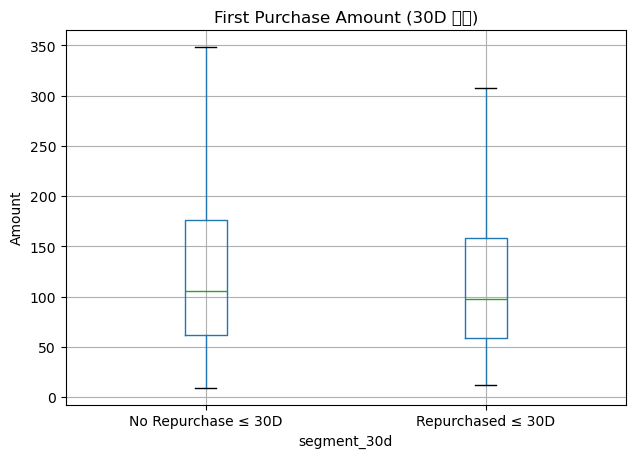

In [31]:
#첫 구매 금액 비교
df_amount_30d = df_30d.merge(
    first_orders[["customer_unique_id", "payment_value"]],
    on="customer_unique_id",
    how="left"
)

df_amount_30d.boxplot(
    column="payment_value",
    by="segment_30d",
    showfliers=False,
    figsize=(7,5)
)
plt.title("First Purchase Amount (30D 기준)")
plt.suptitle("")
plt.ylabel("Amount")
plt.show()

30일 내 재구매 여부에 따라
첫 구매 금액의 중앙값과 분포는 유의미한 차이를 보이지 않는다.


✅ merged shape: (93357, 7)
NA ratio (item_count): 0.0
NA ratio (category_count): 0.0


<Figure size 800x500 with 0 Axes>

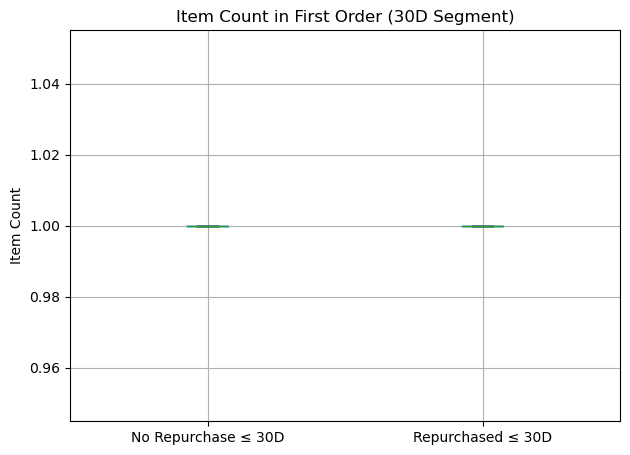

<Figure size 800x500 with 0 Axes>

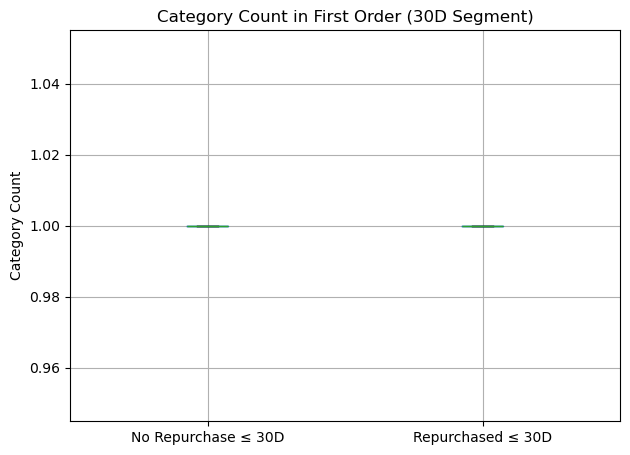

item_count                                      \
                         count mean  std  min  25%  50%  75%   max   
segment_30d                                                          
No Repurchase ≤ 30D   91934.00 1.14 0.53 1.00 1.00 1.00 1.00 21.00   
Repurchased ≤ 30D      1423.00 1.24 0.81 1.00 1.00 1.00 1.00 15.00   

                    category_count                                     
                             count mean  std  min  25%  50%  75%  max  
segment_30d                                                            
No Repurchase ≤ 30D       91934.00 0.99 0.15 0.00 1.00 1.00 1.00 3.00  
Repurchased ≤ 30D          1423.00 1.01 0.19 0.00 1.00 1.00 1.00 3.00

In [32]:
# =========================================================
# Step 3-?. 30일 재구매 vs 미재구매 : 첫 구매 "상품 수 / 카테고리 수" 비교
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# [0] 필수 전제 체크
# -----------------------------
required = ["orders_base", "df_30d"]
for name in required:
    if name not in globals():
        raise NameError(f"❌ '{name}' 가 없습니다. 앞 셀에서 먼저 생성/로드 해주세요.")

# orders_base에 필요한 컬럼 확인
need_cols_orders = ["order_id", "customer_unique_id", "order_purchase_timestamp"]
missing = [c for c in need_cols_orders if c not in orders_base.columns]
if missing:
    raise ValueError(f"❌ orders_base에 필요한 컬럼이 없습니다: {missing}")

# df_30d에 필요한 컬럼 확인
need_cols_df = ["customer_unique_id", "segment_30d"]
missing = [c for c in need_cols_df if c not in df_30d.columns]
if missing:
    raise ValueError(f"❌ df_30d에 필요한 컬럼이 없습니다: {missing}")

# -----------------------------
# [1] items + products 로드
# - items: 주문 내 상품 row (order_item_id)
# - products: product_id -> product_category_name 매핑
# -----------------------------
base_path = "../data/raw/"

items = pd.read_csv(base_path + "olist_order_items_dataset.csv")
products = pd.read_csv(base_path + "olist_products_dataset.csv")

# 필요한 컬럼만
items = items[["order_id", "order_item_id", "product_id"]].copy()
products = products[["product_id", "product_category_name"]].copy()

# items에 category 붙이기
items_enriched = items.merge(products, on="product_id", how="left")

# -----------------------------
# [2] "첫 구매 주문(first_order)" 추출
# - customer_unique_id별 가장 이른 구매(order_purchase_timestamp)의 order_id
# -----------------------------
first_orders = (
    orders_base
    .sort_values("order_purchase_timestamp")
    .groupby("customer_unique_id", as_index=False)
    .first()[["customer_unique_id", "order_id"]]
    .rename(columns={"order_id": "first_order_id"})
)

# -----------------------------
# [3] 첫 구매 주문 기준으로 item_count / category_count 계산
# - item_count: 첫 주문의 상품 row 수
# - category_count: 첫 주문에 포함된 서로 다른 카테고리 수
# -----------------------------
first_order_items = first_orders.merge(
    items_enriched,
    left_on="first_order_id",
    right_on="order_id",
    how="left"
)

first_order_features = (
    first_order_items
    .groupby("customer_unique_id", as_index=False)
    .agg(
        item_count=("order_item_id", "count"),
        category_count=("product_category_name", "nunique")
    )
)

# -----------------------------
# [4] df_30d에 붙이기 (분석용 테이블 완성)
# -----------------------------
df_items_30d = df_30d.merge(first_order_features, on="customer_unique_id", how="left")

# 결측(이상 케이스) 체크: 보통 거의 없어야 함
print("✅ merged shape:", df_items_30d.shape)
print("NA ratio (item_count):", df_items_30d["item_count"].isna().mean())
print("NA ratio (category_count):", df_items_30d["category_count"].isna().mean())

# -----------------------------
# [5] 발표용 시각화 1) 상품 수 박스플롯
# -----------------------------
plt.figure(figsize=(8, 5))
df_items_30d.boxplot(
    column="item_count",
    by="segment_30d",
    showfliers=False
)
plt.title("Item Count in First Order (30D Segment)")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("Item Count")
plt.tight_layout()
plt.show()

# -----------------------------
# [6] 발표용 시각화 2) 카테고리 수 박스플롯
# -----------------------------
plt.figure(figsize=(8, 5))
df_items_30d.boxplot(
    column="category_count",
    by="segment_30d",
    showfliers=False
)
plt.title("Category Count in First Order (30D Segment)")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("Category Count")
plt.tight_layout()
plt.show()

# -----------------------------
# [7] (옵션) 숫자 요약도 같이 보기
# -----------------------------
summary = (
    df_items_30d
    .groupby("segment_30d")[["item_count", "category_count"]]
    .describe()
)
summary

#### 리뷰점수와의 관계

In [33]:
# 1) 첫 구매 주문 테이블 (이미 만들었으면 skip)
first_orders = (
    orders_base
    .sort_values("order_purchase_timestamp")
    .groupby("customer_unique_id")
    .first()
    .reset_index()
)

# 2) 리뷰 점수 붙이기
first_orders = first_orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

# 3) 30일 기준 세그먼트(df_30d)와 병합
df_review_30d = df_30d.merge(
    first_orders[["customer_unique_id", "review_score"]],
    on="customer_unique_id",
    how="left"
)

df_review_30d.head()

,customer_unique_id,first_purchase_date,second_purchase_date,days_to_second_purchase,segment_30d,review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,NaT,NaN,No Repurchase ≤ 30D,5.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,NaT,NaN,No Repurchase ≤ 30D,4.00
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,NaT,NaN,No Repurchase ≤ 30D,3.00
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,NaT,NaN,No Repurchase ≤ 30D,4.00
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,NaT,NaN,No Repurchase ≤ 30D,5.00


In [34]:
df_review_30d.groupby("segment_30d")["review_score"].describe()

,count,mean,std,min,25%,50%,75%,max
segment_30d,,,,,,,,
No Repurchase ≤ 30D,91423.00,4.15,1.29,1.00,4.00,5.00,5.00,5.00
Repurchased ≤ 30D,1612.00,4.11,1.33,1.00,4.00,5.00,5.00,5.00


<Figure size 700x500 with 0 Axes>

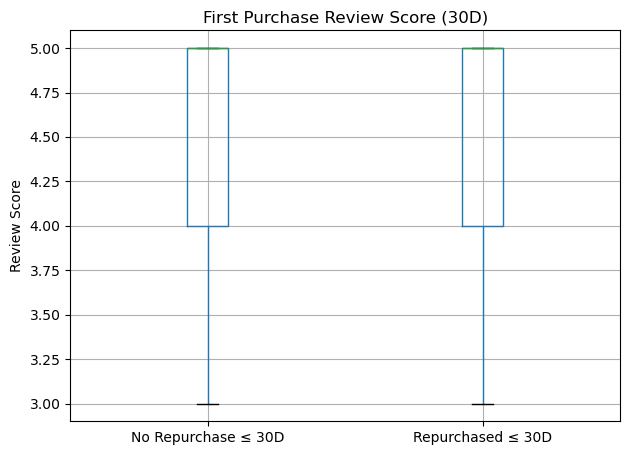

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

df_review_30d.boxplot(
    column="review_score",
    by="segment_30d",
    showfliers=False
)

plt.title("First Purchase Review Score (30D)")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("Review Score")

plt.tight_layout()
plt.show()

🧠 Step 3-X. 재구매의 성격 규명: 보충 구매(Replenishment) 가설 검증

📌 왜 이 분석을 하는가?

앞선 분석에서 확인한 바와 같이,
	•	첫 구매 금액
	•	배송 소요 시간
	•	리뷰 여부 및 리뷰 점수
	•	상품 수 / 카테고리 수

모두에서
30일 내 재구매 고객과 미재구매 고객 간 유의미한 차이는 발견되지 않았다.

즉,

“더 많이 쓰거나”,
“더 좋은 경험을 했거나”,
“배송이 빨랐거나”,
“리뷰가 좋았기 때문에”
재구매했다고 보기 어렵다.

⸻

🔍 새롭게 제기되는 핵심 가설

그렇다면 남는 질문은 하나다.

“이 고객들은 처음 산 게 모자라서 다시 산 게 아닐까?”

즉, 재구매는
	•	충성도나 만족도의 결과가 아니라
	•	필요 기반 보충 구매 (replenishment) 일 가능성이다.

    이를 검증하기 위해
재구매 고객의 두 번째 주문이:
	•	첫 구매와 같은 카테고리인지
	•	아니면 전혀 다른 카테고리인지

를 확인한다.

⸻

🎯 이 분석으로 알 수 있는 것

이 분석을 통해 다음을 판단할 수 있다.
	•	재구매 고객이 같은 카테고리를 반복 구매한다면
→ 재구매는 “의도된 반복 소비”
	•	다른 카테고리를 구매한다면
→ 재구매는 “탐색적 구매 또는 우연적 재방문”

즉,
Olist의 재구매는 ‘관계’가 아니라 ‘필요’에서 발생하는지를 판별하는 단계다.

,definition,same_ratio_pct,n_customers
0,strict(mode==mode),60.58,1423
1,loose(any overlap),62.67,1393


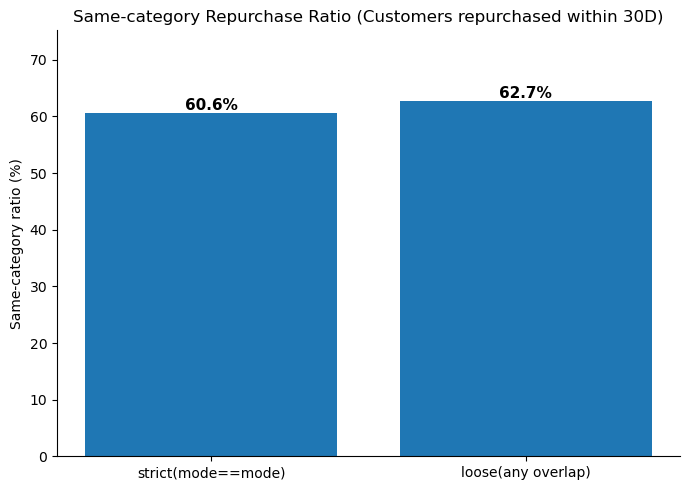

,category,customers
0,cama_mesa_banho,164
1,moveis_decoracao,92
2,beleza_saude,89
3,esporte_lazer,84
4,informatica_acessorios,83
5,eletrodomesticos,47
6,utilidades_domesticas,37
7,relogios_presentes,35
8,fashion_bolsas_e_acessorios,30
9,telefonia,28


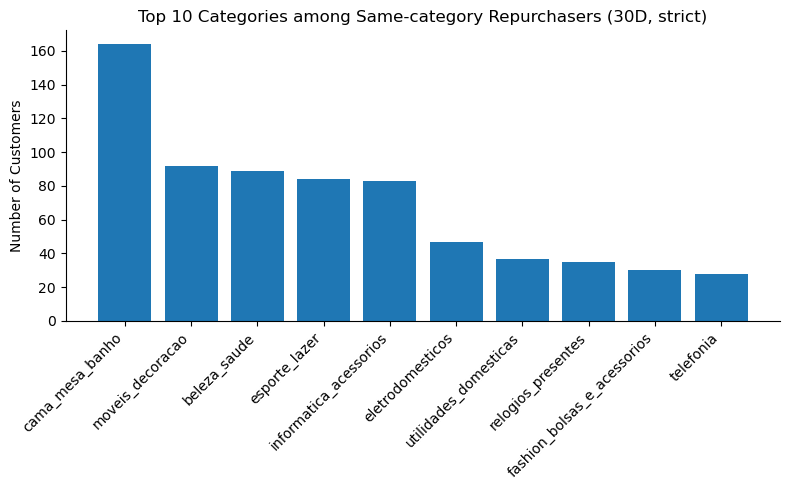

In [36]:
# =========================================================
# Step 3-X) "처음 산 게 모자라서 다시 샀나?" (Same-category repurchase)
# - 30일 내 재구매 고객의 2번째 주문이 1번째 주문과 "같은 카테고리"인지 확인
# =========================================================

import pandas as pd
import numpy as np

# -----------------------------
# [0] 준비물 체크 (없으면 여기서 만들어도 됨)
# -----------------------------
# 필수 DF 가정:
# 1) orders_base : delivered + customer_unique_id 포함 + order_purchase_timestamp 포함
# 2) customer_purchase_dates : customer_unique_id, first_purchase_date, second_purchase_date, days_to_second_purchase
# 3) df_30d : customer_purchase_dates 기반으로 30일 세그먼트 붙인 DF (segment_30d)
# 4) items (또는 order_items) : order_id, product_id, (가능하면 product_category_name)
# 5) products : product_id -> product_category_name 매핑

# ※ 네 노트북에서 변수명이 다를 수 있으니,
#    아래 "BASE_..." 변수에 실제 DF 이름만 맞춰주면 됨.

BASE_ORDERS = orders_base
BASE_CUST_DATES = customer_purchase_dates

# df_30d가 이미 있으면 그대로 사용
# 없으면 아래에서 생성(30일 내 재구매 vs 미재구매)
if "df_30d" in globals():
    DF30 = df_30d.copy()
else:
    DF30 = BASE_CUST_DATES.copy()
    DF30["segment_30d"] = np.where(
        DF30["days_to_second_purchase"].le(30),
        "Repurchased ≤ 30D",
        "No Repurchase ≤ 30D"
    )

# -----------------------------
# [1] 고객별 첫 주문 / 두번째 주문 order_id 추출
# -----------------------------
# 고객별 주문을 시간순으로 정렬 후 1번째/2번째 주문을 뽑는다.
cust_orders = (
    BASE_ORDERS[["customer_unique_id", "order_id", "order_purchase_timestamp"]]
    .sort_values(["customer_unique_id", "order_purchase_timestamp"])
)

first_second_orders = (
    cust_orders
    .groupby("customer_unique_id")["order_id"]
    .agg(first_order_id="first",
         second_order_id=lambda s: s.iloc[1] if len(s) > 1 else np.nan)
    .reset_index()
)

# 30일 내 재구매 고객만 분석 대상으로 (핵심)
rep30_ids = DF30.loc[DF30["segment_30d"] == "Repurchased ≤ 30D", "customer_unique_id"]
rep30_orders = first_second_orders[first_second_orders["customer_unique_id"].isin(rep30_ids)].copy()

# second_order_id 없는 케이스 제거(이론상 30일 재구매면 있어야 함)
rep30_orders = rep30_orders.dropna(subset=["second_order_id"])

# -----------------------------
# [2] (order_id -> 카테고리) 주문별 카테고리 집계 테이블 만들기
# -----------------------------
# 주문에는 여러 아이템이 있을 수 있어 "주문 카테고리"를 정의해야 함.
# 추천 정의: 주문에서 가장 많이 나온 카테고리(최빈값) = 대표 카테고리
# (또는 1개라도 같으면 same_category로 보는 방식도 아래에서 제공)

# items에 product_category_name이 없다면 products와 merge
if "product_category_name" not in items.columns:
    # products DF 필요: product_id, product_category_name
    items_cat = items.merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
else:
    items_cat = items.copy()

# 주문별 카테고리 리스트(중복 제거)
order_cat_list = (
    items_cat
    .dropna(subset=["product_category_name"])
    .groupby("order_id")["product_category_name"]
    .apply(lambda x: list(pd.unique(x)))
    .reset_index()
    .rename(columns={"product_category_name": "cat_list"})
)

# 주문별 대표 카테고리(최빈값) - tie면 첫 번째로
order_cat_mode = (
    items_cat
    .dropna(subset=["product_category_name"])
    .groupby(["order_id", "product_category_name"])
    .size()
    .reset_index(name="cnt")
    .sort_values(["order_id", "cnt"], ascending=[True, False])
    .groupby("order_id")
    .head(1)
    .rename(columns={"product_category_name": "cat_mode"})
    [["order_id", "cat_mode"]]
)

# -----------------------------
# [3] 첫 주문/둘째 주문 카테고리 붙이기
# -----------------------------
rep30 = rep30_orders.merge(
    order_cat_list.rename(columns={"order_id": "first_order_id", "cat_list": "first_cat_list"}),
    on="first_order_id",
    how="left"
).merge(
    order_cat_list.rename(columns={"order_id": "second_order_id", "cat_list": "second_cat_list"}),
    on="second_order_id",
    how="left"
).merge(
    order_cat_mode.rename(columns={"order_id": "first_order_id", "cat_mode": "first_cat_mode"}),
    on="first_order_id",
    how="left"
).merge(
    order_cat_mode.rename(columns={"order_id": "second_order_id", "cat_mode": "second_cat_mode"}),
    on="second_order_id",
    how="left"
)

# -----------------------------
# [4] Same-category 정의 2가지
# -----------------------------
# A) strict: 대표 카테고리(최빈값)가 동일하면 same
rep30["same_category_strict"] = rep30["first_cat_mode"].eq(rep30["second_cat_mode"])

# B) loose: 첫 주문 카테고리 리스트와 두 번째 주문 카테고리 리스트가 1개라도 겹치면 same
def has_overlap(a, b):
    if not isinstance(a, list) or not isinstance(b, list):
        return np.nan
    return len(set(a) & set(b)) > 0

rep30["same_category_loose"] = rep30.apply(
    lambda r: has_overlap(r["first_cat_list"], r["second_cat_list"]),
    axis=1
)

# -----------------------------
# [5] 결과 요약 테이블
# -----------------------------
summary = pd.DataFrame({
    "definition": ["strict(mode==mode)", "loose(any overlap)"],
    "same_ratio_pct": [
        rep30["same_category_strict"].mean() * 100,
        rep30["same_category_loose"].mean() * 100
    ],
    "n_customers": [
        rep30["same_category_strict"].notna().sum(),
        rep30["same_category_loose"].notna().sum()
    ]
})

display(summary)

# -----------------------------
# [6] 발표용 시각화 (막대 + 퍼센트 라벨)
# -----------------------------
import matplotlib.pyplot as plt

plot_df = summary.copy()
x = plot_df["definition"]
y = plot_df["same_ratio_pct"]

plt.figure(figsize=(7, 5))
bars = plt.bar(x, y)
plt.title("Same-category Repurchase Ratio (Customers repurchased within 30D)")
plt.ylabel("Same-category ratio (%)")
plt.ylim(0, max(10, y.max() * 1.2))  # 너무 작으면 보기 좋게 최소 10%까지 확보

for bar, val in zip(bars, y):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{val:.1f}%",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

plt.xticks(rotation=0)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# -----------------------------
# [7] 어떤 카테고리에서 "same repeat"이 많이 나오나? (top10)
# - strict 기준으로 same인 고객의 first_cat_mode 집계
# -----------------------------
top_cats = (
    rep30.loc[rep30["same_category_strict"] == True, "first_cat_mode"]
    .value_counts()
    .head(10)
    .reset_index()
)
top_cats.columns = ["category", "customers"]

display(top_cats)

plt.figure(figsize=(8, 5))
bars = plt.bar(top_cats["category"], top_cats["customers"])
plt.title("Top 10 Categories among Same-category Repurchasers (30D, strict)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

4️⃣ 그렇다면 재구매는 왜 발생했는가?

30일 이내 재구매 고객을 대상으로 카테고리 반복 구매 여부를 분석한 결과:
	•	60% 이상의 고객이
👉 첫 구매와 동일한 카테고리를 다시 구매
	•	특히:
	•	cama_mesa_banho
	•	beleza_saude
	•	utilidades_domesticas
	•	informatica_acessorios
등 소모성·생활 밀착형 카테고리가 상위에 위치

👉 이는 재구매가
**“만족해서 돌아온 것”보다는
“처음에 부족해서 다시 산 것”**일 가능성을 강하게 시사함

⸻

🧠 최종 결론 (한 문장 요약)

Olist의 재구매는 ‘충성도’의 결과라기보다,
첫 구매에서 수요를 충분히 충족하지 못한
소수 고객의 ‘보충 구매’에 가깝다.